In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial

import os



from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_20948/4080581513.py:47: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


### HELPER FUNCTIONS - to do: move to .py file 

In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
def in_burst_to_burst_range_ms(is_burst_array, ms_convert=True):

    """Convert boolean array of whether each idx is in burst, to range of bursts in ms"""

    s = pd.Series(is_burst_array)
    grp = s.eq(False).cumsum()
    arr = grp.loc[s.eq(True)] \
             .groupby(grp) \
             .apply(lambda x: [x.index.min(), x.index.max()])
    
    if ms_convert:
        arr = [[i[0] / lfp_one_ms, i[1] / lfp_one_ms] for i in arr.values]
    else:
        arr = arr.values
    
    
    
    return arr
    

In [5]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [6]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [7]:
def spk_lfp_class(spk_times_ms, ranges_not_burst_low_ms, gamma_bursts_ms):
    """Classify spikes based on whether they occur during LFP gamma burst 
    or not during gamma oscillations """
    spk_class = []
    spk_idx = []
    spk_idx_ms = []

    for counter, spk in enumerate(spk_times_ms):
        found = False

        for no_burst in ranges_not_burst_low_ms:
            if no_burst[0] <= spk <= no_burst[1]:
                found = True
                spk_class.append('no_gamma')
                spk_idx_ms.append(spk)
                spk_idx.append(counter)
                break

        if not found:
            for burst in gamma_bursts_ms:
                if burst[0] <= spk <= burst[1]:
                    found = True
                    spk_class.append('gamma')
                    spk_idx_ms.append(spk)
                    spk_idx.append(counter)
                    break

    return spk_class, spk_idx, spk_idx_ms

In [8]:
def get_lowest_analytical_amp(gamma_amp, ranges_not_burst, one_ms, thresh=0.25):
    
    no_burst_mean_amp = []
    no_burst_mean_ranges = []

    for r in ranges_not_burst:

        am_range = gamma_amp[slice(*r)]
        #take mean of analytic amplitude for that range 
        mean_am = np.nanmean(am_range)
        no_burst_mean_amp.append(mean_am)
        no_burst_mean_ranges.append(r)
        
    #Select 25% (default) no burst sections with lowest analytical amplitude 
    n_lowest = int(len(no_burst_mean_amp) * thresh)
    no_burst_mean_amp_array = np.array(no_burst_mean_amp, dtype=np.float32)
    lowest_amp_no_bursts = no_burst_mean_amp_array.argsort()[:n_lowest]

    #get the index range of the sections with lowest amplitude 
    ranges_not_burst_low =  [ranges_not_burst[i] for i in lowest_amp_no_bursts]

    #convert to ms
    ranges_not_burst_low_ms = [(x/one_ms, y/one_ms) for x,y in ranges_not_burst_low]
    
    return ranges_not_burst_low_ms
    

In [9]:
def visualize_lfp_gamma_regions(lfp_times, lfp_filt, gamma_groups, no_gamma_groups,title=None, xlim=None, plot_spk=False, spk_gamma=None, spk_nogamma=None):
    plt.plot(lfp_times, lfp_filt, label="LFP")
    #loop through gamma groups
    plt.axvspan(gamma_groups[0][0], gamma_groups[0][1], alpha=0.3, color="red", label="gamma")
    for g in gamma_groups[1:]:
        plt.axvspan(g[0], g[1], alpha=0.3, color="red")

    #loop through non gamma groups
    plt.axvspan(no_gamma_groups[0][0], no_gamma_groups[0][1], alpha=0.3, color="green", label="low amp no gamma")
    for ng in no_gamma_groups[1:]:
        plt.axvspan(ng[0], ng[1], alpha=0.3, color="green")
    
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage (mV)')
    if xlim ==None:
        plt.title(title + " full recording")
        if plot_spk:
            plt.eventplot(spk_gamma,lineoffsets = 80, linelengths=10, color='darkred', label = 'gamma spikes')
            plt.eventplot(spk_nogamma,lineoffsets = 80, linelengths=10,color = 'darkgreen', label = 'no gamma spikes')
            
        plt.legend(loc="lower left")
        plt.show()
    else:
        plt.xlim(xlim)
        plt.title(title + " from " +str(xlim[0])+ " ms to " + str(xlim[1]) + " ms")
        if plot_spk:
            plt.eventplot(spk_gamma,lineoffsets = 80, linelengths=10, color='darkred', label = 'gamma spikes')
            plt.eventplot(spk_nogamma,lineoffsets = 80, linelengths=10,color = 'darkgreen', label = 'no gamma spikes')
        plt.legend(loc="lower left")
        

In [10]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c42 = get_patch_fs_metadata(metadata_dir, 42)
patch_fs_c14 = get_patch_fs_metadata(metadata_dir, 14)

patch_fs = {'c42':patch_fs_c42, 'c14':patch_fs_c14}


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [11]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c14', 'c42']

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 

#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)



## Cell 42  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

#### Step 0: Get loaded data

In [12]:
lfp_c42= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_c42 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [13]:
#get cell number 
cell_num = lfp_c42.split('/')[len(lfp_c42.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt_c42 = np.load(lfp_c42)
lfp_fs = 2500 # sampling rate
lfp_one_ms = float(lfp_fs / 1000)
lfp_times_c42 = np.arange(0, np.shape(lfp_filt_c42)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt_c42 = np.load(patch_c42)
patch_c42_one_ms = float(patch_fs_c42  / 1000)
patch_times_c42 = np.arange(0, np.shape(patch_filt_c42 )[0]) / patch_c42_one_ms # in ms instead of sec

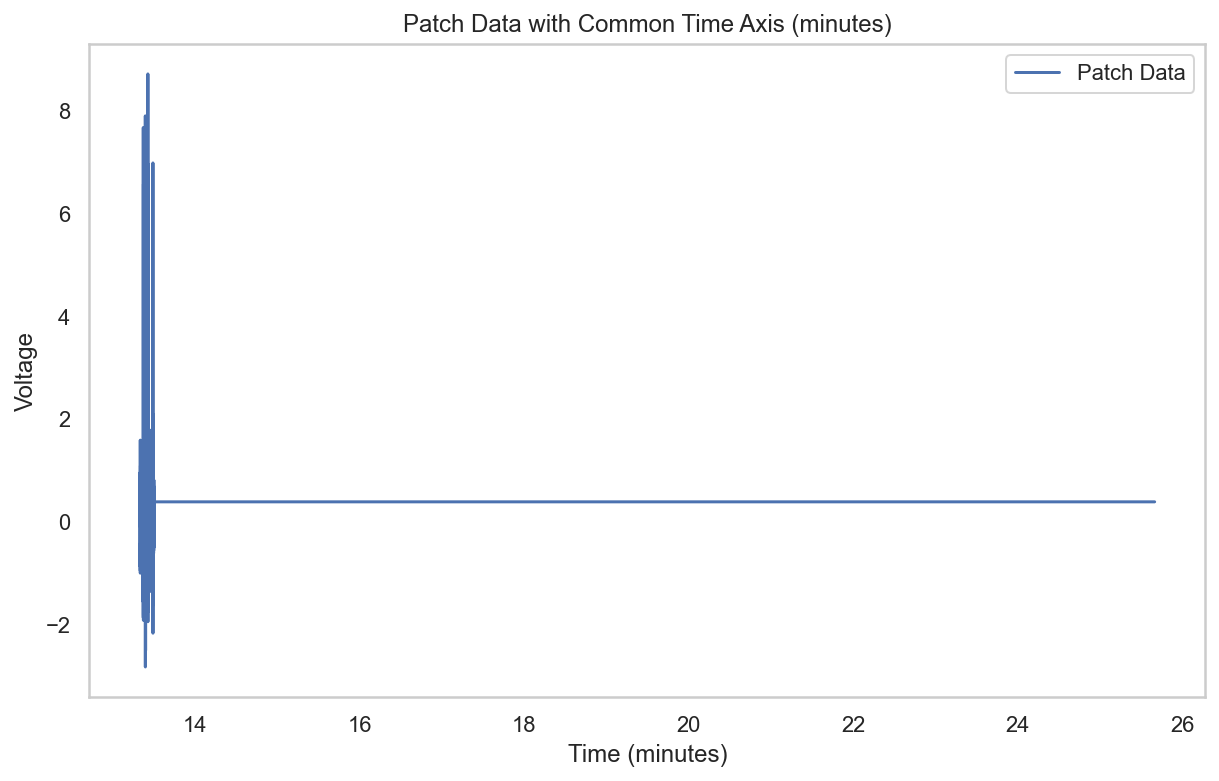

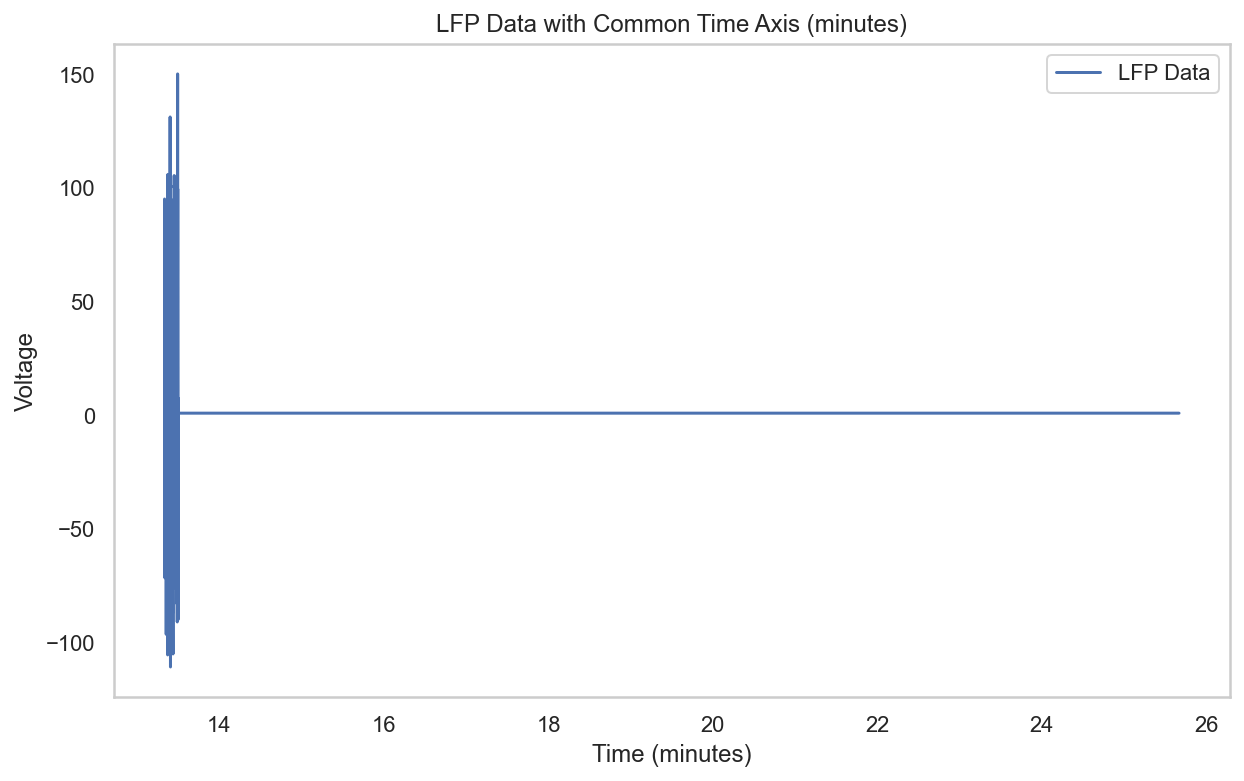

In [14]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times_c42 / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times_c42 / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(800000 / 60000, 1540000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt_c42)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt_c42)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

In [15]:
patch_times_c42[-1]

810034.2800095493

In [16]:
lfp_times_c42[-1]

810034.8

#### Step 1: Align LFP with patch and extracellular - crop the lfp recording from the start alignement pulse of the patch until the end alignment pulse of the patch

### LFP Gamma "burst detection" method

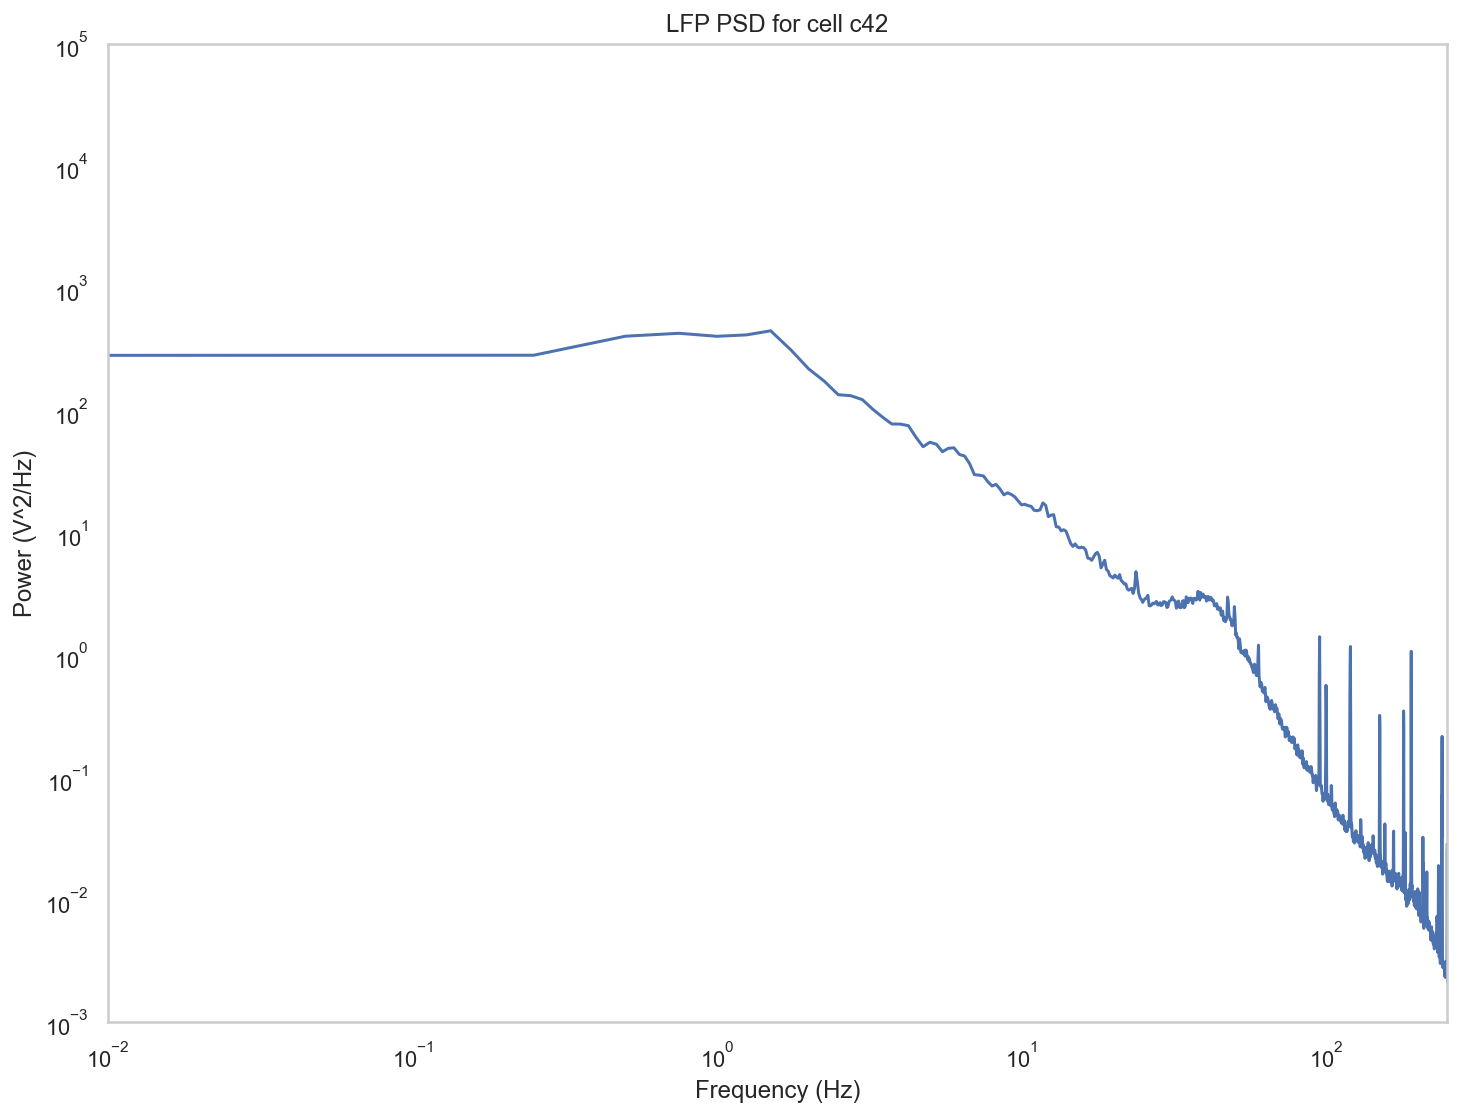

In [17]:
#plot PSD for cell 42
# plot power spectrum
fxx_c42, pxx_c42 = spectral.compute_spectrum(lfp_filt_c42, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx_c42, pxx_c42)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


#### 0. Use specpram to find gamma peaks

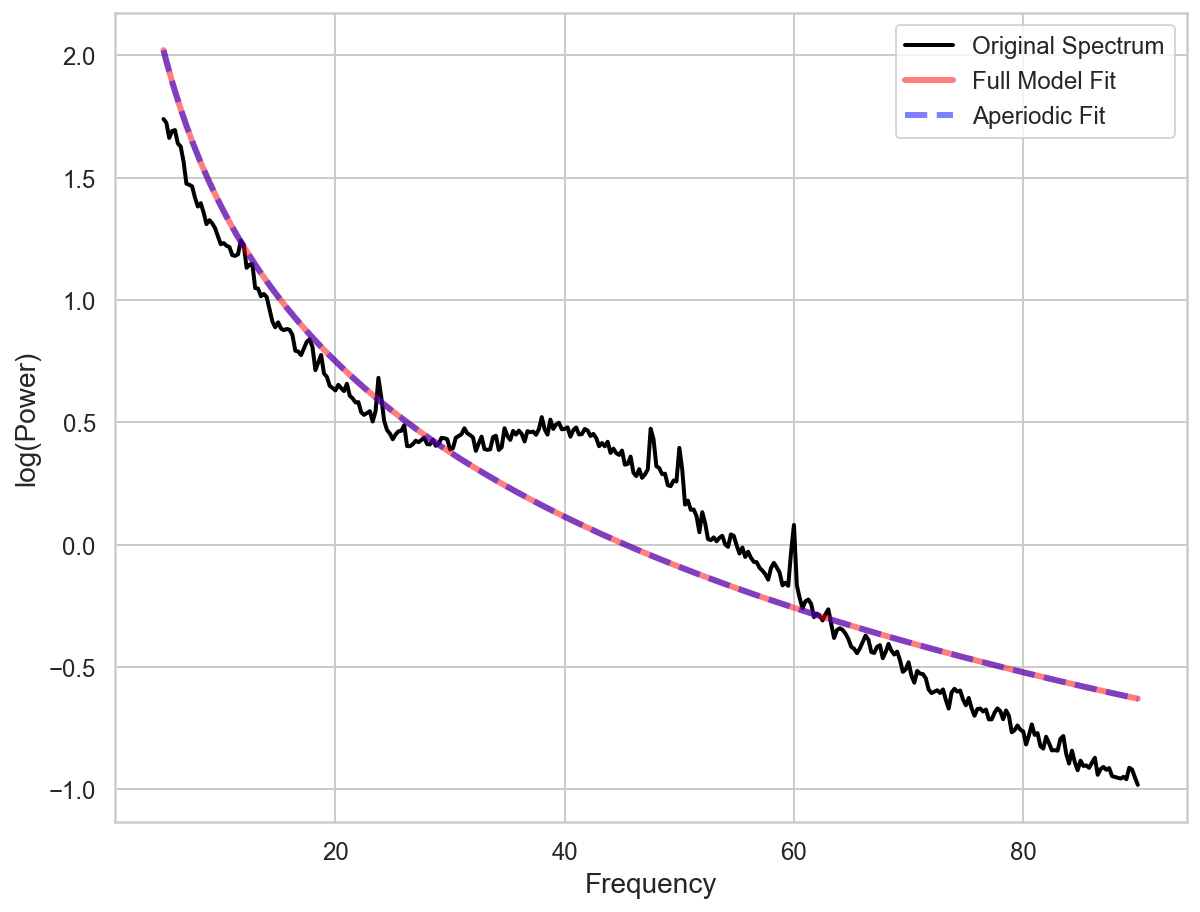

In [18]:
fm_c42 = FOOOF(max_n_peaks=0, verbose=False)
fm_c42.fit(fxx_c42, pxx_c42, freq_range=(5,90))
fm_c42.plot()

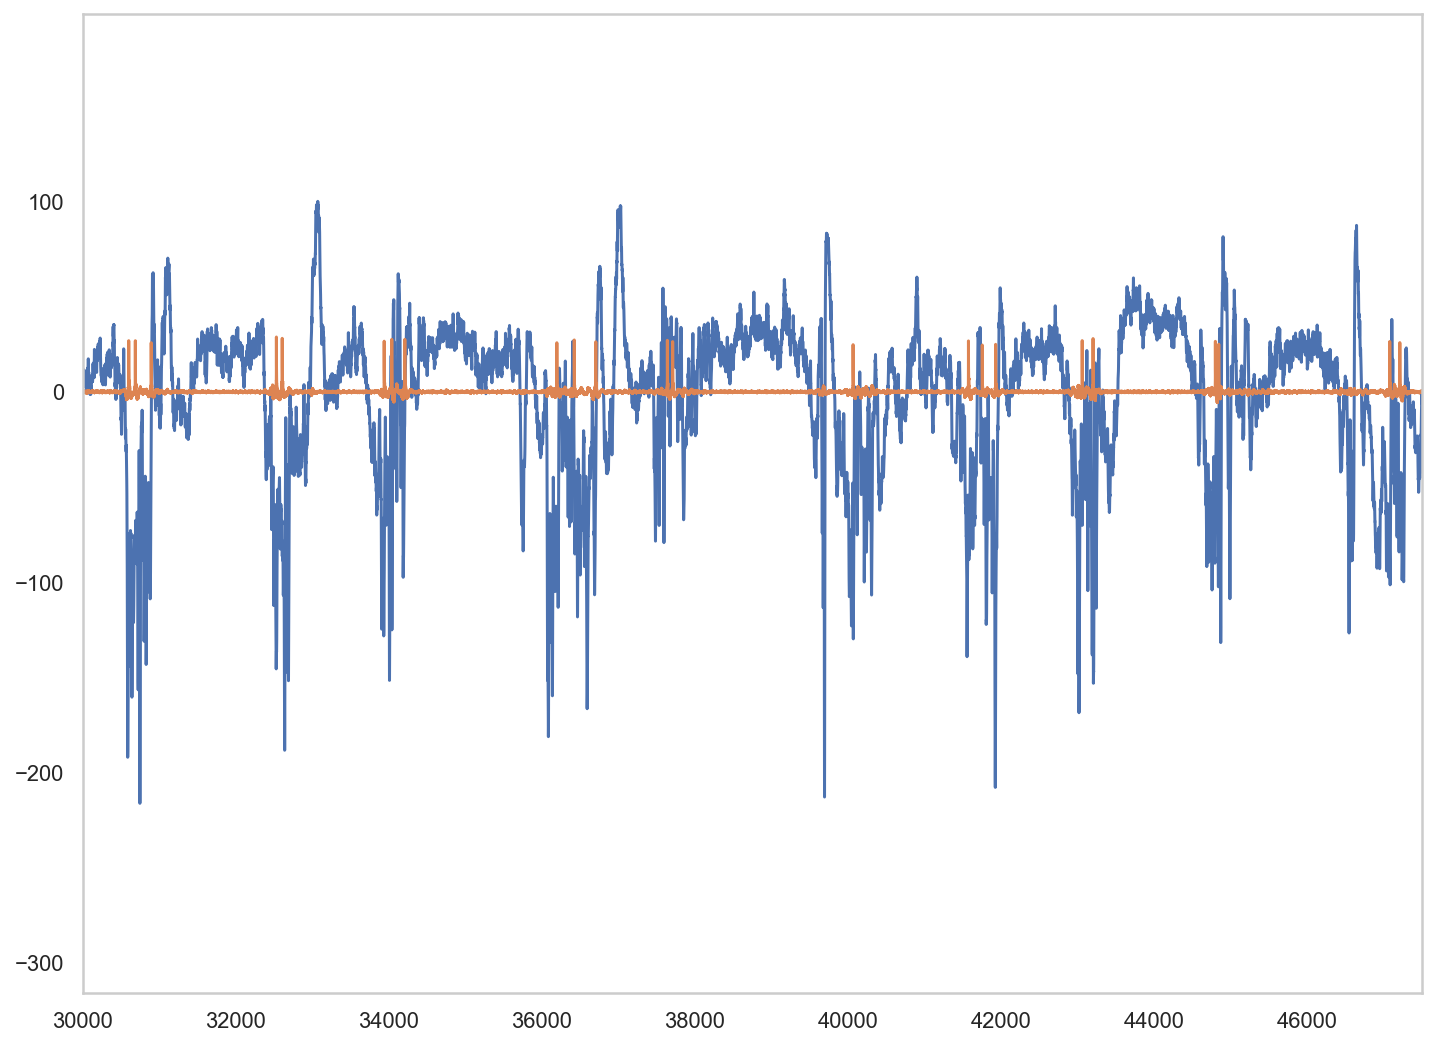

In [19]:
#plot raw LFP and patch data
plt.plot(lfp_times_c42, lfp_filt_c42)
plt.plot(patch_times_c42, patch_filt_c42)
plt.xlim(30000,47500)
plt.show()

#### 1. Filter the signal in +/- 15 Hz around that gamma peak

In [20]:
gamma_peak = 40 #Hz 
gamma_range = [gamma_peak - 15, gamma_peak+15]
#filter LFP data around that range
lfp_filt_gamma_c42 = butter_bandpass(lfp_filt_c42, fs=lfp_fs, filt_freq=gamma_range, order=4)

#### 2. Get the analytic amplitude of the time series 

In [21]:
gamma_amp = amp_by_time(lfp_filt_gamma_c42, lfp_fs, gamma_range)

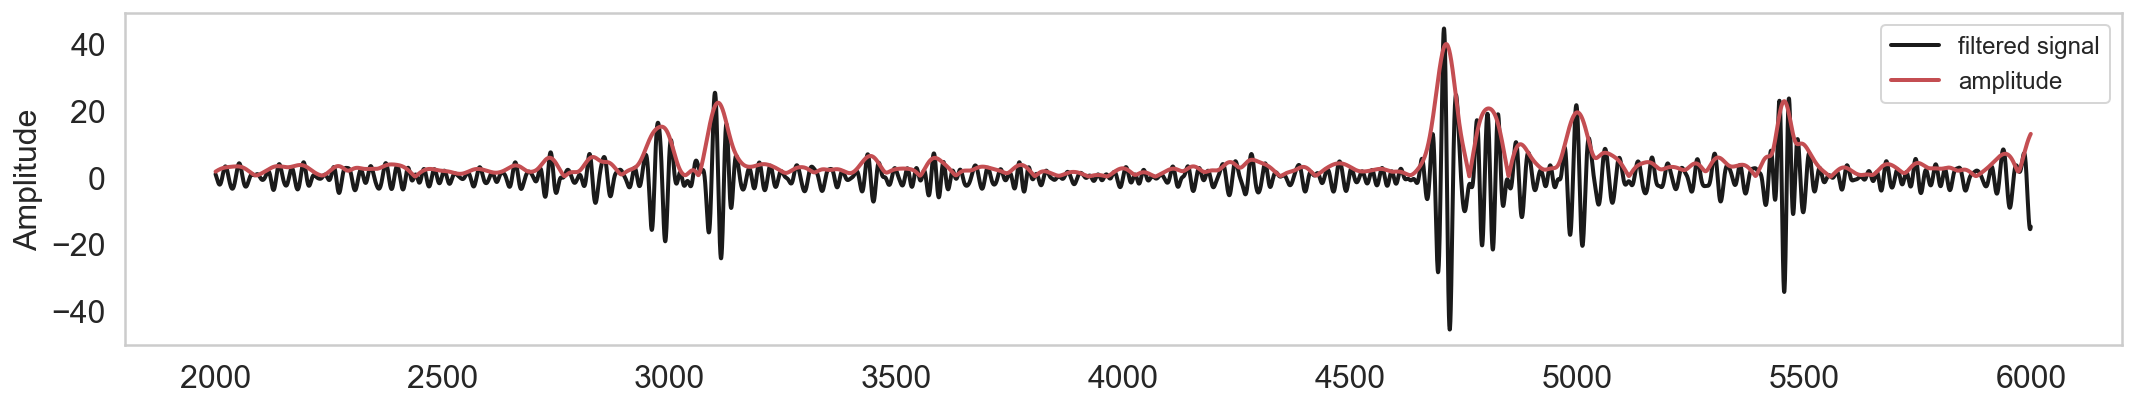

In [22]:
xlim = (2000, 6000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

# Plot the filtered signal and oscillation amplitude
plot_instantaneous_measure(lfp_times_c42[tidx], [lfp_filt_gamma_c42[tidx], gamma_amp[tidx]],
                           measure='amplitude', lw=2, xlabel='',
                           labels=['filtered signal', 'amplitude'])

#### 3. Classify a burst as whenever the gamma analytic amplitude goes above some criterion (3x median, 2std of the mean, whatever), and ends when it drops below another criterion (1.5x mean, 1std of mean)


#### Try 3 different moethods for gamma burst classifcation
#### Method 1: My own code to detect when analytic amplitude goes above some criteria - ignore for now (slower)
#### Method 2: neurodsp burst detection on gamma filtered data
#### Method 3: neurodsp burst detection on unfiltered data 

#### Method 2

In [23]:
xlim = (1000,20000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

In [24]:
###Try neurodsp burst detection method 
is_burst_m2 = detect_bursts_dual_threshold(lfp_filt_c42, lfp_fs, dual_thresh=(3, 1), f_range=(gamma_peak - 15, gamma_peak+15))


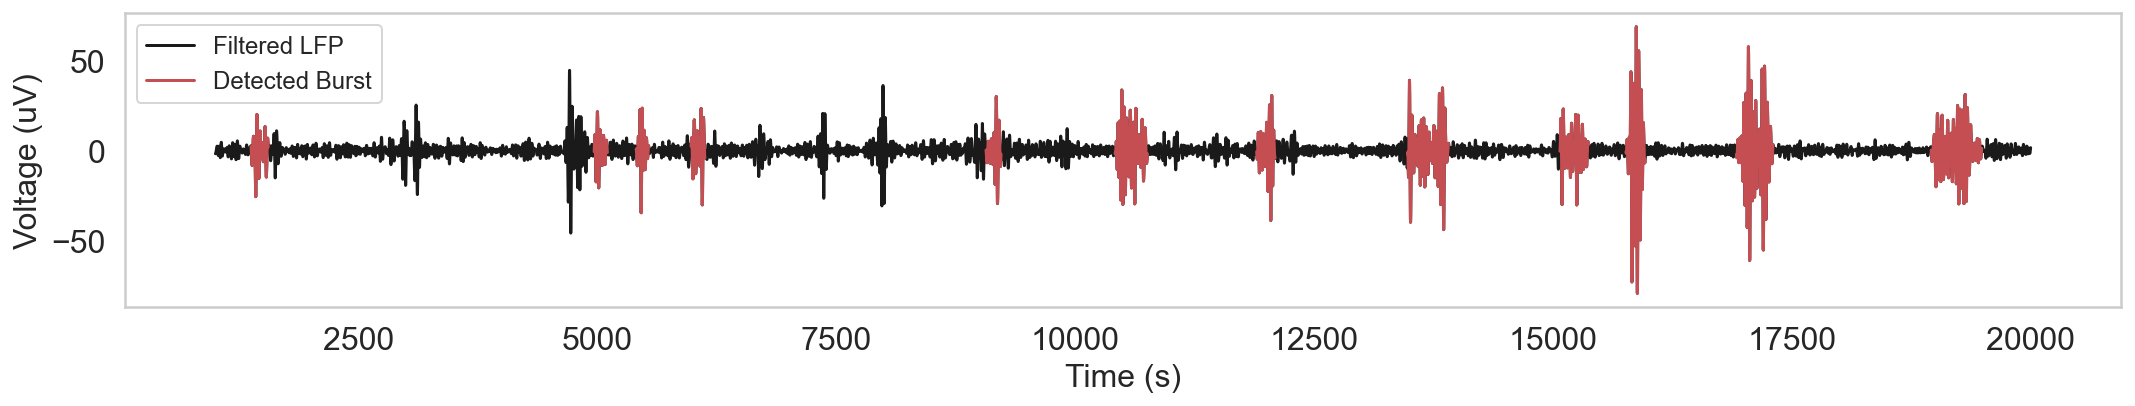

In [25]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_m2[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [26]:
gamma_bursts_ms_m2 = in_burst_to_burst_range_ms(is_burst_m2)


#### Method 3

In [27]:
###Try neurodsp burst detection method 
is_burst_m3 = detect_bursts_dual_threshold(lfp_filt_gamma_c42, lfp_fs, dual_thresh=(2, 1), f_range=(gamma_peak - 15, gamma_peak+15))


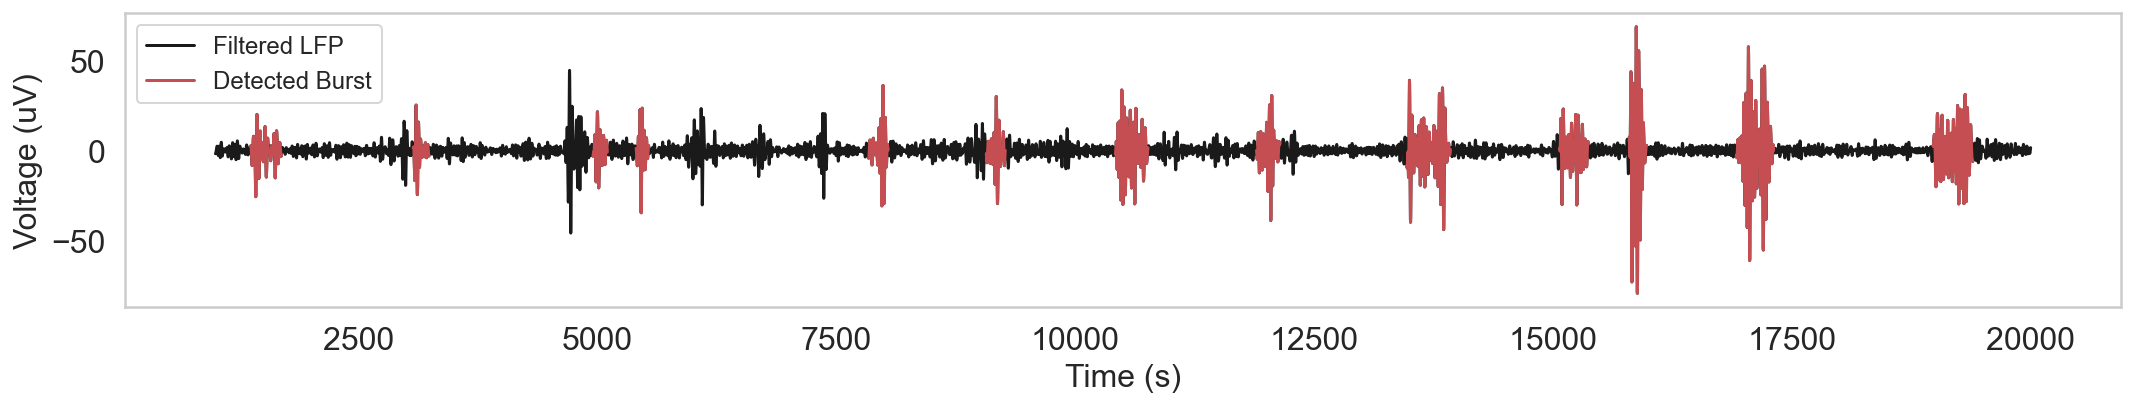

In [28]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_m3[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [29]:
gamma_bursts_ms_m3 = in_burst_to_burst_range_ms(is_burst_m3)

### Load and analyze extracellular spike data - IGNORE EXTRACELLULAR FOR NOW

In [30]:

#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c42npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109


In [31]:
# open and load the data
npx_filt = np.load(npx_path)

In [32]:
npx_times_c42 = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

In [33]:
"""npx_times_c42 [-1]/60000"""

'npx_times_c42 [-1]/60000'

In [34]:
"""plt.plot(npx_filt[0:100000])"""

'plt.plot(npx_filt[0:100000])'

#### Detect extracellular spikes

In [35]:
"""sp_ex = Spike(thresh_amp=41.5, window_length=(5., 5.), smooth_frac=.01)

sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)"""

"sp_ex = Spike(thresh_amp=41.5, window_length=(5., 5.), smooth_frac=.01)\n\nsp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,\n       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))\n\nsp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)"

In [36]:
"""sp_ex.df_features"""

'sp_ex.df_features'

In [37]:
"""sp_ex.plot()"""

'sp_ex.plot()'

In [38]:
"""sp_ex.spike_inds"""

'sp_ex.spike_inds'

### Compute patch clamp spike features for cell 42

#### 4. compare the patched spike waveform for spikes that occur during an obvious gamma burst versus those are are obviously not in gamma. We’ll want to confirm this visually, looking at the time series as well.


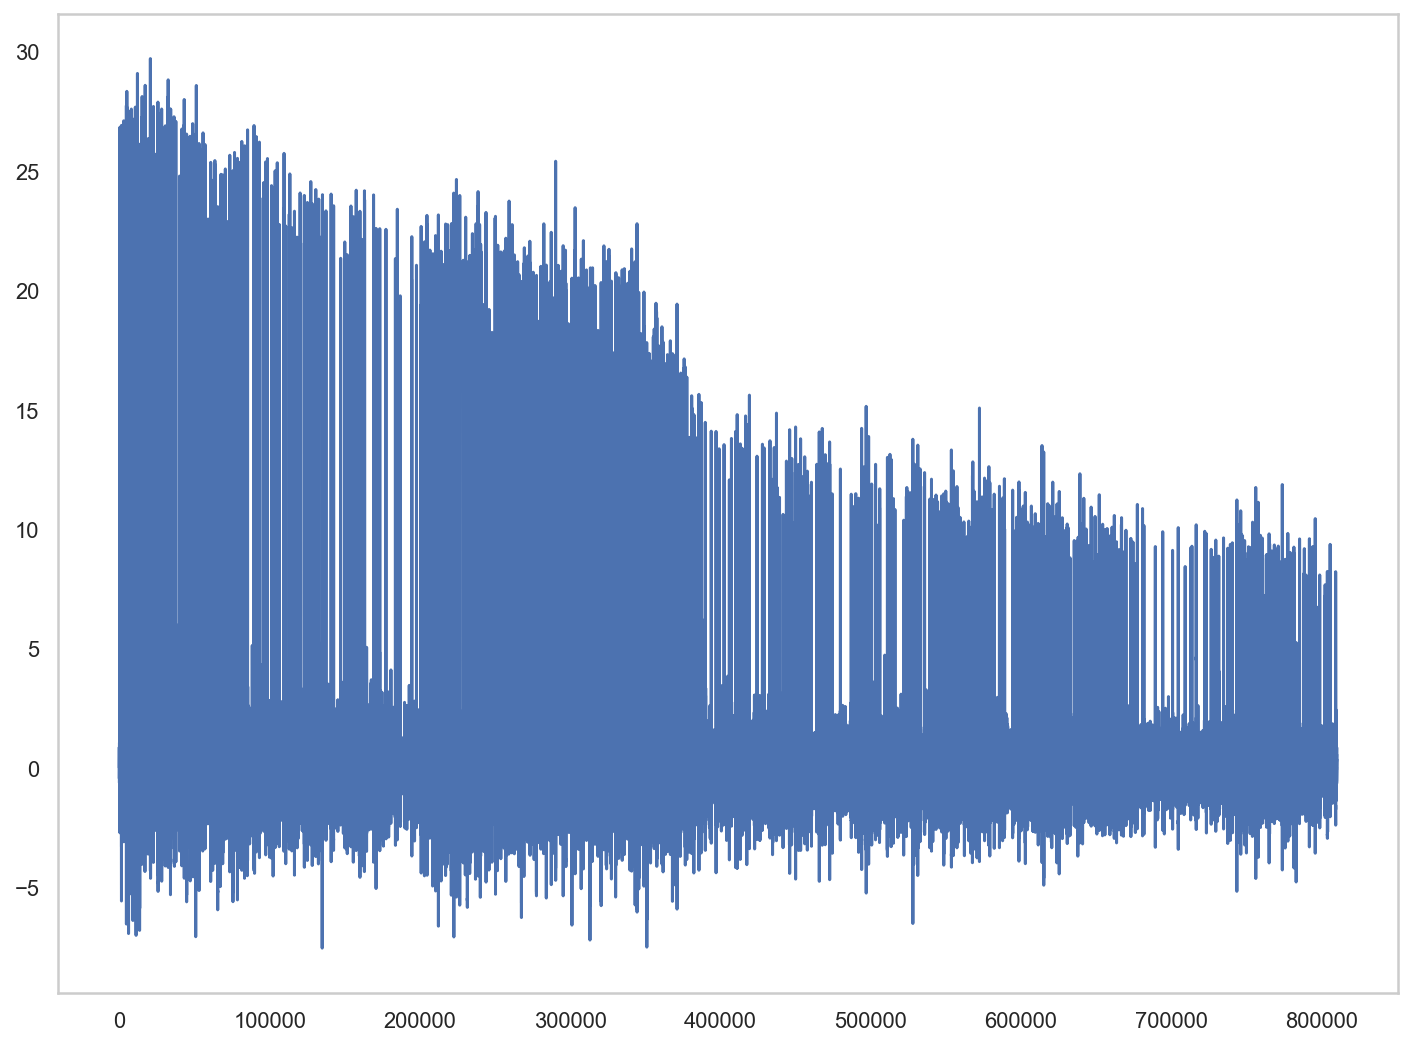

In [39]:
plt.plot(patch_times_c42, patch_filt_c42)

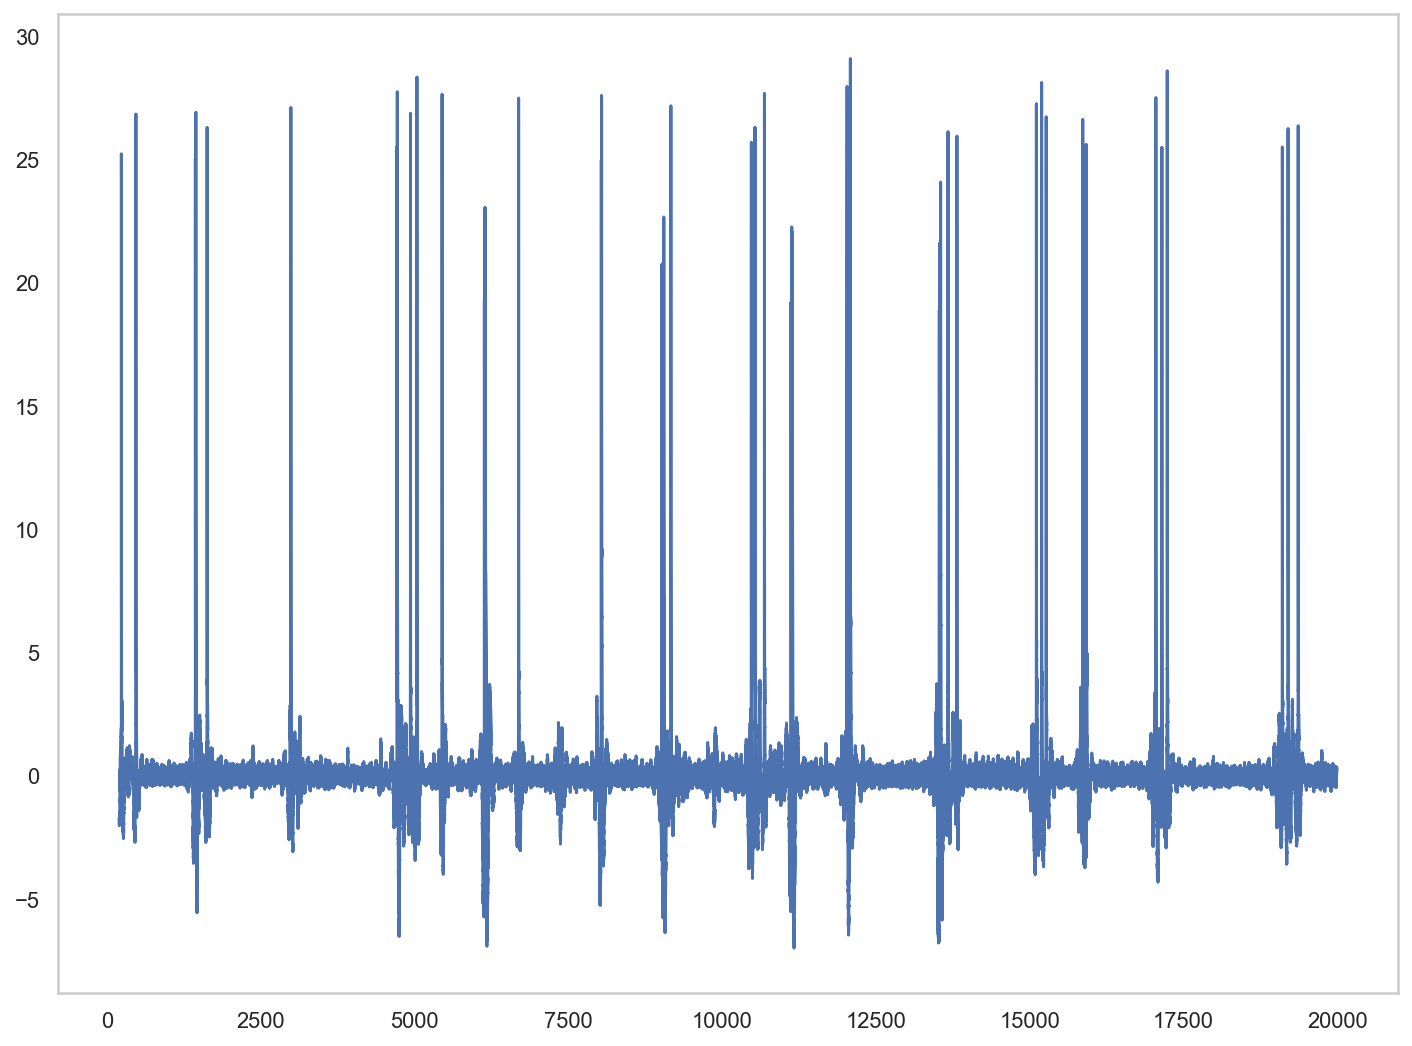

In [40]:
plt.plot(patch_times_c42[10000:1000000], patch_filt_c42[10000:1000000])

In [ ]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c42, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c42, patch_fs_c42, n_jobs=-1, progress=tqdm)

[   11703    11705    23523 ... 39805728 39805730 39805733]
[25.20824606 25.24025972 26.8553058  ... 10.13741906 10.16910887
 10.13957081]


Spike:   0%|          | 0/1479 [00:00<?, ?it/s]

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip

In [58]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,236.247160,0.847685,0.996917
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,966.738253,0.951638,0.987640
2,1.009074,0.70,1.232428,24.959544,1.20,0.629029,1.388962,1.885119,7.736305,0.981525,0.997816
3,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,0.779628,0.821644,0.999190
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.099952,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1474,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,0.279866,0.933486,0.996783
1475,-0.909968,1.30,4.727512,11.674754,3.28,0.151188,0.221733,3.783842,1657.968098,0.933486,0.994164
1476,0.095210,1.06,3.676545,11.090664,3.14,-0.015259,0.258909,2.899848,15992.021665,0.072322,0.997072
1477,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,21926.827000,0.450267,0.997292


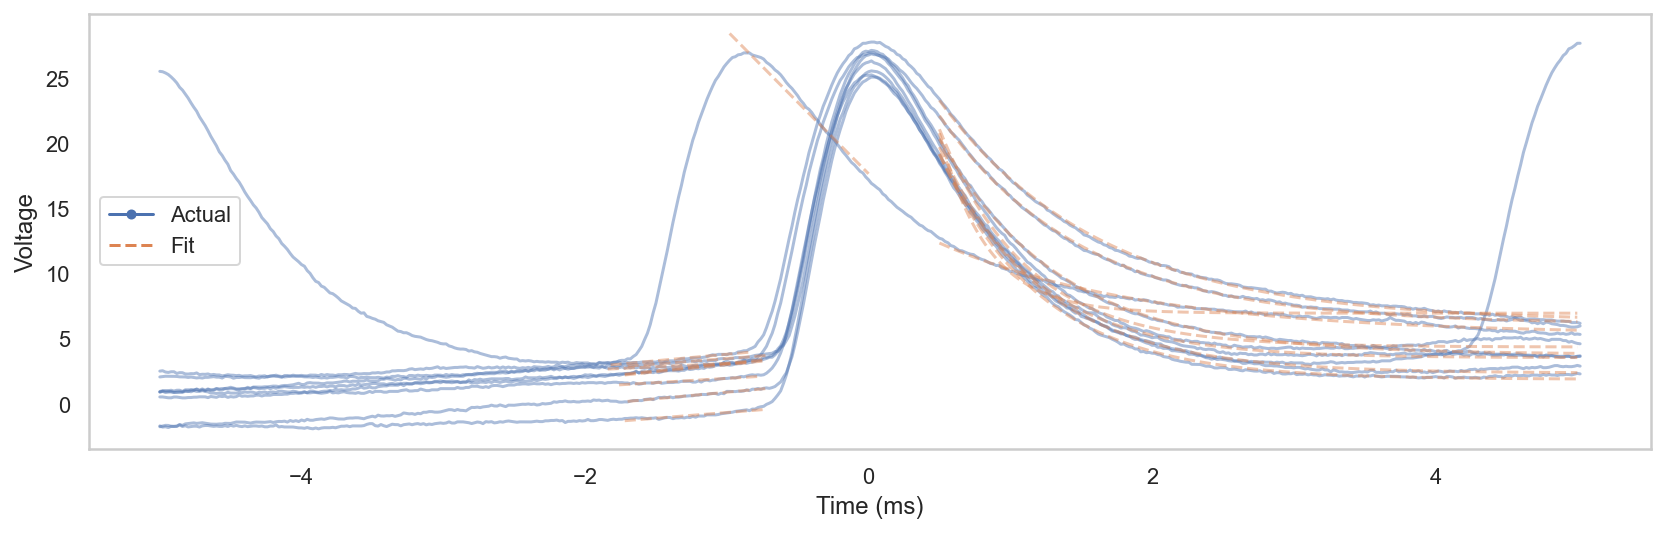

In [59]:
# First 10 fits
sp.plot(inds=np.arange(
    10), mode='full')

### Use detected spike indeces to determine if a spike occured during gamma peak or not

#### A) Get converted indices for gamma 'bursts'

In [60]:
gamma_bursts_ms_m2

[[150.4, 274.4],
 [1372.8, 1552.8],
 [4963.2, 5102.8],
 [5404.0, 5534.0],
 [5978.0, 6124.4],
 [9065.6, 9223.2],
 [10417.2, 10754.8],
 [11898.0, 12091.6],
 [13478.8, 13906.4],
 [15072.4, 15371.2],
 [15763.6, 15964.4],
 [16920.8, 17304.4],
 [18958.8, 19156.8],
 [19159.2, 19487.6],
 [20755.2, 20921.2],
 [22617.2, 22910.0],
 [23729.6, 23853.2],
 [25558.8, 25817.2],
 [28034.0, 28420.0],
 [30554.4, 30684.8],
 [30692.4, 30845.2],
 [32369.6, 32599.2],
 [33805.6, 34214.8],
 [36046.0, 36196.0],
 [36199.2, 36436.8],
 [36489.2, 36616.0],
 [37553.2, 37714.0],
 [37728.4, 37880.0],
 [39972.4, 40186.0],
 [40272.4, 40402.0],
 [41487.6, 41759.2],
 [42902.0, 43043.6],
 [43046.4, 43333.6],
 [44593.2, 44766.0],
 [44899.6, 45034.0],
 [48572.0, 48770.4],
 [48773.6, 48984.4],
 [48995.6, 49174.8],
 [50681.6, 51020.0],
 [51078.8, 51269.2],
 [52842.4, 53214.0],
 [55459.6, 55646.4],
 [56757.2, 57281.2],
 [58904.0, 59025.6],
 [59035.6, 59206.0],
 [59215.6, 59413.6],
 [60720.8, 60848.4],
 [60852.8, 61174.0],
 [6222

In [61]:
gamma_bursts_ms_m3

[[149.2, 273.6],
 [348.0, 519.2],
 [1368.4, 1559.2],
 [1571.6, 1692.0],
 [3069.6, 3234.0],
 [4950.8, 5102.4],
 [5402.4, 5534.4],
 [7837.2, 8041.6],
 [9068.8, 9267.2],
 [10420.0, 10761.6],
 [11896.8, 12137.2],
 [13473.2, 13926.8],
 [15069.6, 15370.4],
 [15797.2, 15979.6],
 [16921.2, 17309.6],
 [18980.0, 19154.0],
 [19160.4, 19392.8],
 [20537.6, 20714.0],
 [20757.2, 20927.2],
 [20965.6, 21194.4],
 [22613.6, 22914.4],
 [23552.4, 23866.4],
 [25454.4, 25819.2],
 [28025.2, 28419.2],
 [28554.0, 28679.2],
 [28693.6, 28822.4],
 [30550.0, 30684.4],
 [30690.0, 30912.8],
 [32362.4, 32769.2],
 [33807.6, 34268.4],
 [36039.2, 36406.8],
 [36493.2, 36624.8],
 [37418.8, 37717.2],
 [37725.2, 37927.2],
 [39621.2, 39749.6],
 [39982.8, 40184.8],
 [40274.0, 40404.0],
 [41487.2, 41757.6],
 [42903.6, 43334.8],
 [44592.8, 44737.6],
 [44770.0, 44901.6],
 [44907.2, 45036.8],
 [47019.6, 47286.8],
 [48569.2, 48947.6],
 [49079.6, 49206.4],
 [50680.8, 50884.8],
 [50888.4, 51024.8],
 [51086.0, 51269.6],
 [52792.8, 532

#### B) Get converted indices for lowest amp no gamma 'bursts'. Select areas not in bursts with the lowest analytic amplitude

In [62]:
ranges_not_burst_m2 = in_burst_to_burst_range_ms(np.invert(is_burst_m2), ms_convert=False)
ranges_not_burst_m3 = in_burst_to_burst_range_ms(np.invert(is_burst_m3), ms_convert=False)

#### Select ranges with lowest analytical amplitude 

In [63]:
not_burst_ms_m2 = get_lowest_analytical_amp(gamma_amp,ranges_not_burst_m2, lfp_one_ms,thresh=1)
not_burst_ms_m3 = get_lowest_analytical_amp(gamma_amp,ranges_not_burst_m3, lfp_one_ms,thresh=1)

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_20948/2299523990.py:10: RuntimeWarning: Mean of empty slice
  mean_am = np.nanmean(am_range)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_20948/2299523990.py:10: RuntimeWarning: Mean of empty slice
  mean_am = np.nanmean(am_range)
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_20948/2299523990.py:10: RuntimeWarning: Mean of empty slice
  mean_am = np.nanmean(am_range)


#### Visualize regions in gamma burst and low amp no gamma 

##### Gamma detection method 2

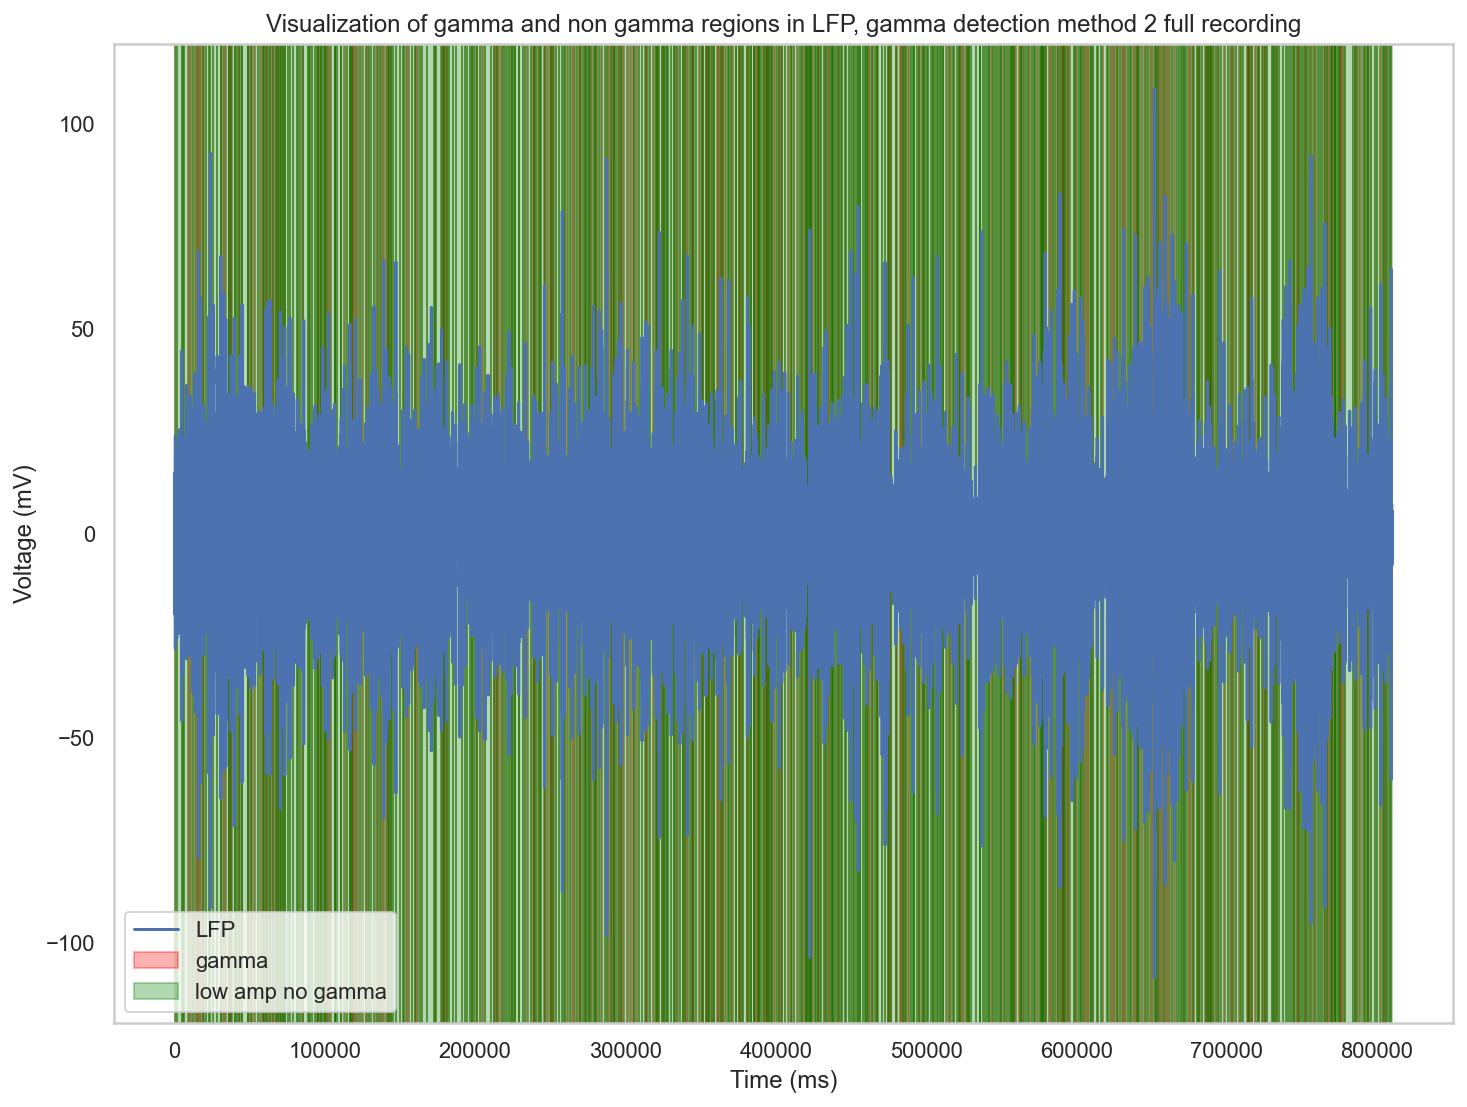

In [64]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', xlim=None)



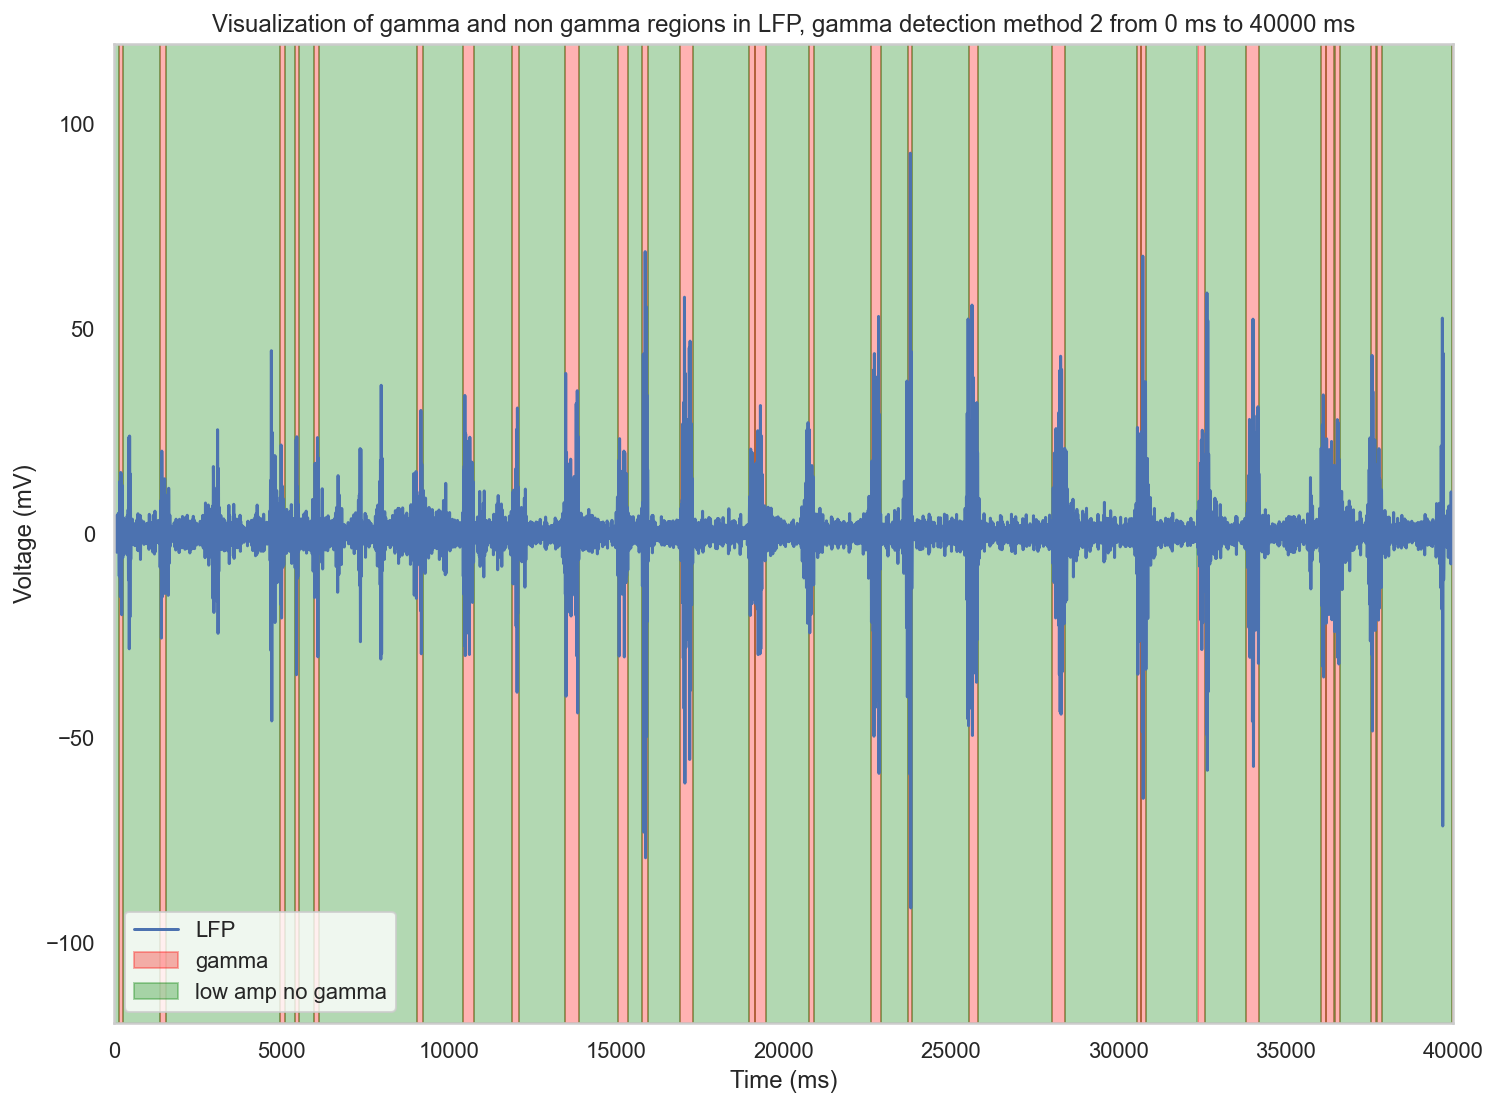

In [65]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', xlim=(0,40000))



###### Gamma detection method 3

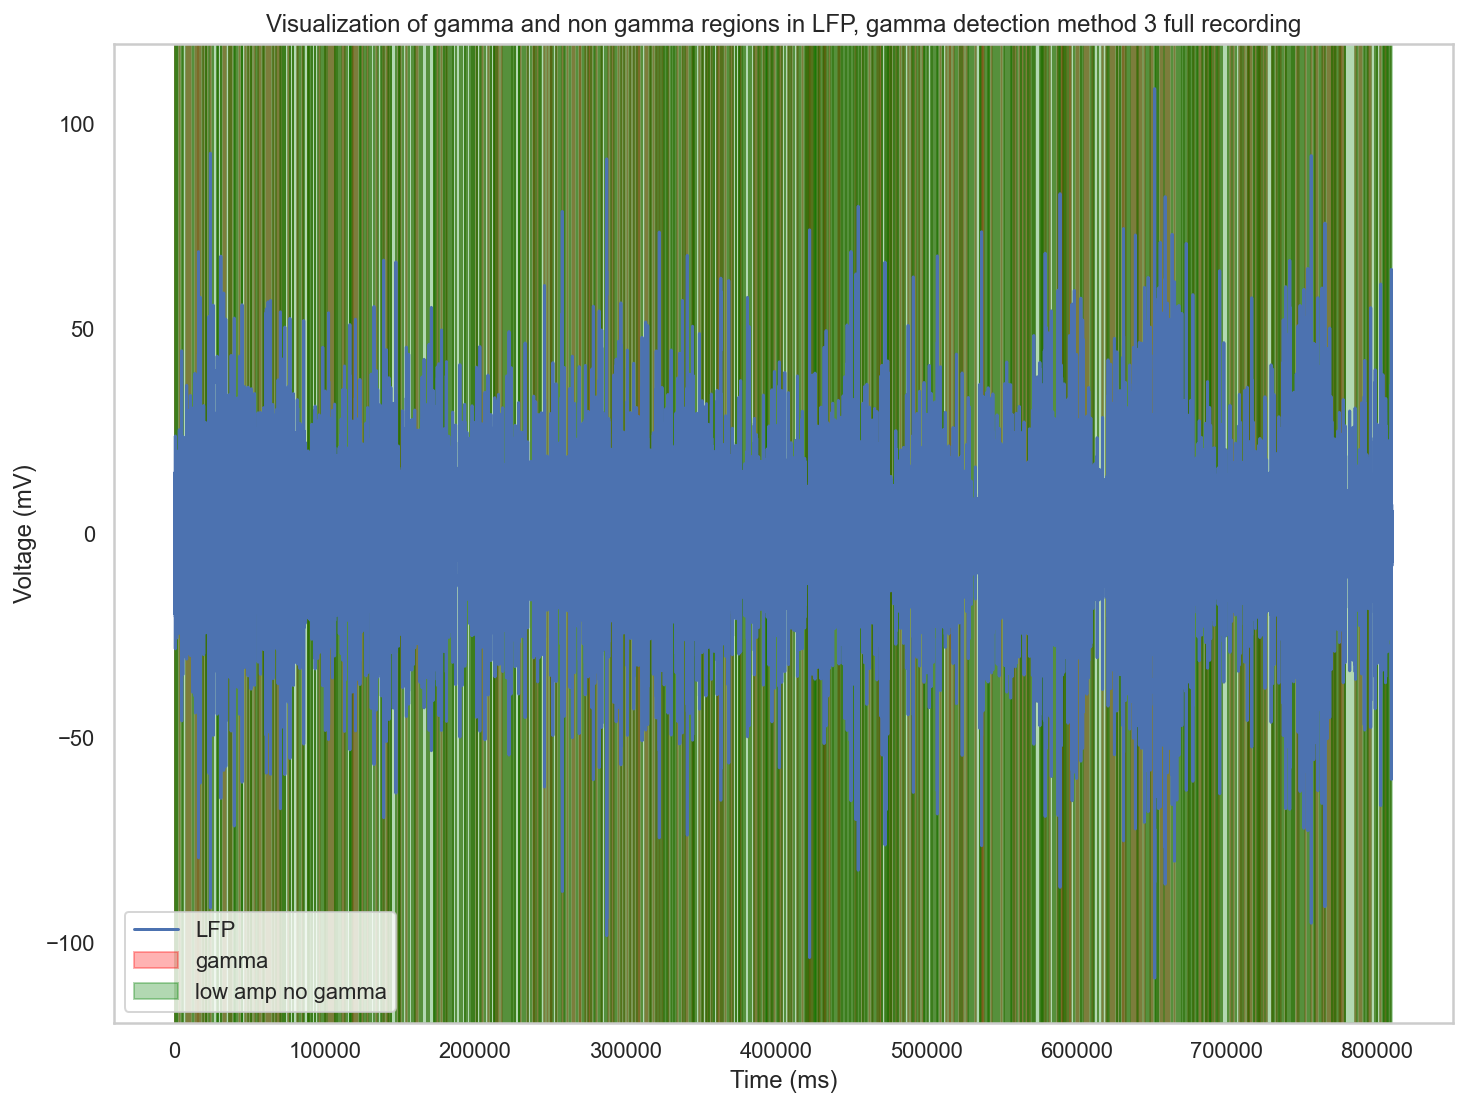

In [66]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=None)



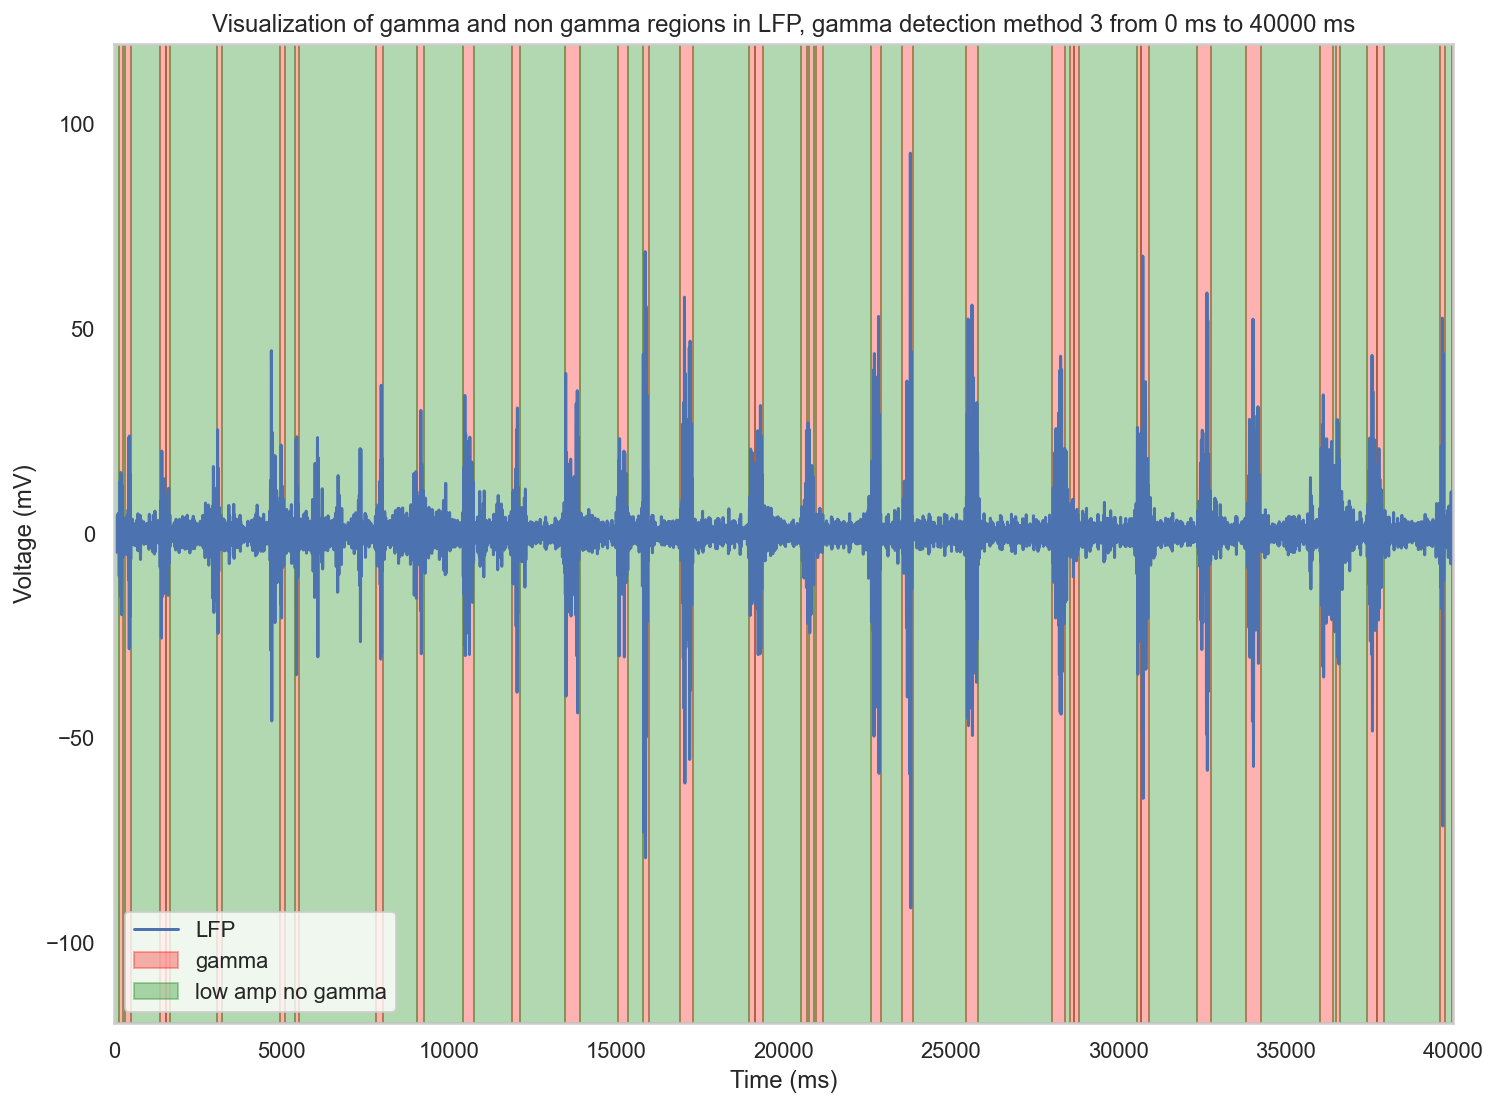

In [67]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=(0,40000))



#### C) Determine what spikes are in which group 

##### C.0) spikes in gamma vs non gamma regions 

In [68]:
spk_times_ms = patch_times_c42[sp.spike_inds]

In [69]:
spk_class_m2, spk_idx_m2, spk_idx_ms_m2 =  spk_lfp_class(spk_times_ms, not_burst_ms_m2, gamma_bursts_ms_m2)

spk_class_m3, spk_idx_m3, spk_idx_ms_m3 =  spk_lfp_class(spk_times_ms, not_burst_ms_m3, gamma_bursts_ms_m3)


In [70]:
occurrence_m2 = {item: spk_class_m2.count(item) for item in spk_class_m2}
occurrence_m3 = {item: spk_class_m3.count(item) for item in spk_class_m3}

In [71]:
occurrence_m2

{'gamma': 984, 'no_gamma': 494}

In [72]:
occurrence_m3

{'gamma': 1088, 'no_gamma': 389}

##### C.1) Distrubition of spikes in no gamma group by gamma analytical amplitude

In [73]:
spk_idx_m2

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [74]:
spk_class_m2

['gamma',
 'no_gamma',
 'gamma',
 'gamma',
 'gamma',
 'gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'gamma',
 'gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'gamma',
 'gamma',
 'gamma',
 'gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_gamma',
 'no_g

In [75]:
spk_idx_ms_m2

[233.98823923905283,
 470.23539954038785,
 1436.9736523896484,
 1444.709957266668,
 1445.4895848899334,
 1445.5895371493266,
 1627.7025537634036,
 2989.2522312150813,
 4714.20833336789,
 4719.245927241299,
 4720.145497575835,
 4720.265440287108,
 4720.305421190865,
 4720.405373450258,
 4933.78345680247,
 5038.5933960019875,
 5447.338165563791,
 6135.049691091506,
 6139.86738999425,
 6145.184850193958,
 6145.9045064615875,
 6145.944487365345,
 6146.1443918841305,
 6150.88212897936,
 6151.261947565054,
 6151.801689765775,
 6151.981603832683,
 6152.061565640197,
 6152.161517899591,
 6152.481365129648,
 6152.561326937162,
 6152.661279196555,
 6152.761231455948,
 6691.423947776796,
 8035.581932094089,
 8039.839898344231,
 8040.43961190059,
 8040.559554611861,
 8040.659506871254,
 8040.699487775011,
 8040.979354101311,
 8041.019335005069,
 8041.079306360704,
 8041.179258620097,
 8041.239229975733,
 9020.63143886415,
 9041.801327403591,
 9045.719455971797,
 9051.516687016592,
 9052.1963623804

##### C.2) Distrubition of number of spikes PER gamma region

In [76]:
# Initialize variables to track subgroups and their counts
subgroup_counts = {'gamma': {}, 'no_gamma': {}}

subgroup_durations = {'gamma': {}, 'no_gamma': {}}
current_group = None
current_subgroup = 0
current_subgroup_start_time = None

# Iterate through the groups array and time_ms array simultaneously
for group, timestamp in zip(spk_class_m2, spk_idx_ms_m2):
    # Check if the group has changed
    if group != current_group:
        # If a new subgroup starts, update current subgroup count and reset counter
        current_subgroup += 1
        current_group = group
        subgroup_counts[group][current_subgroup] = 0
        current_subgroup_start_time = timestamp
    # Increment the count for the current subgroup
    subgroup_counts[group][current_subgroup] = subgroup_counts[group].get(current_subgroup, 0) + 1
    # Calculate the duration of the current subgroup
    duration = timestamp - current_subgroup_start_time
    # Update the duration of the current subgroup
    subgroup_durations[group][current_subgroup] = int(duration)

# Print subgroup counts and durations for each group
for group, counts in subgroup_counts.items():
    print(f"Subgroup counts for {group}: {counts}")
    print(f"Subgroup durations for {group}: {subgroup_durations[group]}")

Subgroup counts for gamma: {1: 1, 3: 4, 5: 2, 7: 4, 9: 28, 11: 3, 13: 2, 15: 6, 17: 1, 19: 5, 21: 5, 23: 2, 25: 33, 27: 4, 29: 13, 31: 1, 33: 9, 35: 5, 37: 5, 39: 6, 41: 8, 43: 1, 45: 1, 47: 23, 49: 36, 51: 1, 53: 2, 55: 4, 57: 6, 59: 2, 61: 7, 63: 6, 65: 3, 67: 2, 69: 4, 71: 36, 73: 6, 75: 5, 77: 1, 79: 25, 81: 1, 83: 4, 85: 14, 87: 1, 89: 4, 91: 2, 93: 6, 95: 51, 97: 3, 99: 3, 101: 39, 103: 64, 105: 41, 107: 3, 109: 45, 111: 4, 113: 68, 115: 7, 117: 7, 119: 11, 121: 7, 123: 21, 125: 1, 127: 1, 129: 3, 131: 22, 133: 2, 135: 2, 137: 13, 139: 13, 141: 2, 143: 9, 145: 3, 147: 8, 149: 15, 151: 1, 153: 6, 155: 1, 157: 2, 159: 34, 161: 3, 163: 30, 165: 3, 167: 5, 169: 1, 171: 1, 173: 3, 175: 1, 177: 1, 179: 2, 181: 2, 183: 3, 185: 3, 187: 4, 189: 10, 191: 23, 193: 2, 195: 5, 197: 15, 199: 5}
Subgroup durations for gamma: {1: 0, 3: 8, 5: 408, 7: 1521, 9: 7333, 11: 1878, 13: 134, 15: 2412, 17: 0, 19: 2483, 21: 4114, 23: 141, 25: 6878, 27: 4054, 29: 5211, 31: 0, 33: 3580, 35: 5, 37: 1908, 39: 

#### E) Compare features of gamma and no gamma spikes

In [71]:
#Get features for gamma spikes
idx_gamma_m2 = np.where(np.array(spk_class_m2) == 'gamma')[0]
#get spike_idx 
spk_idx_gamma_m2 = np.asarray(spk_idx_m2)[np.asarray(idx_gamma_m2)]
spk_gamma_features_m2 = sp.df_features.iloc[spk_idx_gamma_m2]

In [72]:
#Get features for gamma spikes
idx_gamma_m3 = np.where(np.array(spk_class_m3) == 'gamma')[0]
#get spike_idx 
spk_idx_gamma_m3 = np.asarray(spk_idx_m3)[np.asarray(idx_gamma_m3)]
spk_gamma_features_m3 = sp.df_features.iloc[spk_idx_gamma_m3]

In [73]:
#Get features for no gamma spikes
idx_no_gamma_m2 = np.where(np.array(spk_class_m2) == 'no_gamma')[0]
#get spike_idx 
spk_idx_no_gamma_m2 = np.asarray(spk_idx_m2)[np.asarray(idx_no_gamma_m2)]
spk_no_gamma_features_m2 = sp.df_features.iloc[spk_idx_no_gamma_m2]

In [74]:
#Get features for no gamma spikes
idx_no_gamma_m3 = np.where(np.array(spk_class_m3) == 'no_gamma')[0]
#get spike_idx 
spk_idx_no_gamma_m3 = np.asarray(spk_idx_m3)[np.asarray(idx_no_gamma_m3)]
spk_no_gamma_features_m3 = sp.df_features.iloc[spk_idx_no_gamma_m3]

#### Visualize categorized spikes and LFP groups


In [75]:
gamma_spks_m2 = np.asarray(spk_idx_ms_m2)[np.asarray(idx_gamma_m2)]
no_gamma_spks_m2 = np.asarray(spk_idx_ms_m2)[np.asarray(idx_no_gamma_m2)]

gamma_spks_m3 = np.asarray(spk_idx_ms_m3)[np.asarray(idx_gamma_m3)]
no_gamma_spks_m3 = np.asarray(spk_idx_ms_m3)[np.asarray(idx_no_gamma_m3)]

###### Method 2

In [ ]:


visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', xlim=(0,1000), plot_spk=True, spk_gamma= gamma_spks_m2, spk_nogamma=no_gamma_spks_m2)


In [ ]:

visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m2, not_burst_ms_m2, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', plot_spk=True, spk_gamma= gamma_spks_m2, spk_nogamma=no_gamma_spks_m2)


##### Method 3

In [ ]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=(0,40000), plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)


In [ ]:

visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 2', plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)


##### Gamma features

In [ ]:
spk_gamma_features_m2

In [ ]:
spk_gamma_features_m3

#### Plot gamma features

In [ ]:


# Ensure inflection times are between 0 and 2 ms
df_drop_gamma_m2 = spk_gamma_features_m2.loc[spk_gamma_features_m2['inflection_time'] > 0.]
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['r_squared_exp']  >= .5]
df_drop_gamma_m2 = df_drop_gamma_m2.loc[df_drop_gamma_m2['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_gamma_m2[['isi']] = np.log10(df_drop_gamma_m2[['isi']])

# drop no-longer-used QC features
df_drop_gamma_m2 = df_drop_gamma_m2.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_gamma_m2 = df_drop_gamma_m2.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_gamma_m2, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

#### zscore outlier removal

In [ ]:
df_drop_gamma_m2_outliers = df_drop_gamma_m2[(np.abs(stats.zscore(df_drop_gamma_m2, nan_policy='omit')) < 3).all(axis=1)]



#### Plot spike shapes gamma method 2 

##### I am currently only plotting the average waveforms for method 3 

In [ ]:
#REMOVE WEIRD FITS 
spk_gamma_m2_notweird_fits_idx = [i for i in range(len(sp.ramp_poly_params[df_drop_gamma_m2_outliers.index])) if sp.ramp_poly_params[df_drop_gamma_m2_outliers.index][i][1] < 10]


In [ ]:
sp.plot(inds =  df_drop_gamma_m2_outliers.index[spk_gamma_m2_notweird_fits_idx], show_points=True)

In [ ]:
df_drop_gamma_m2_outliers = df_drop_gamma_m2_outliers.iloc[spk_gamma_m2_notweird_fits_idx]

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_gamma_m2_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:


# Ensure inflection times are between 0 and 2 ms
df_drop_gamma_m3 = spk_gamma_features_m3.loc[spk_gamma_features_m3['inflection_time'] > 0.]
df_drop_gamma_m3 = df_drop_gamma_m3.loc[df_drop_gamma_m3['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_gamma_m3 = df_drop_gamma_m3.loc[df_drop_gamma_m3['r_squared_exp']  >= .5]
df_drop_gamma_m3 = df_drop_gamma_m3.loc[df_drop_gamma_m3['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_gamma_m3[['isi']] = np.log10(df_drop_gamma_m3[['isi']])

# drop no-longer-used QC features
df_drop_gamma_m3 = df_drop_gamma_m3.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_gamma_m3 = df_drop_gamma_m3.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_gamma_m3, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
df_drop_gamma_m3_outliers = df_drop_gamma_m3[(np.abs(stats.zscore(df_drop_gamma_m3, nan_policy='omit')) < 3).all(axis=1)]


In [ ]:
sp.plot(inds = df_drop_gamma_m3_outliers.index, show_points=True)

In [ ]:
#REMOVE WEIRD FITS 
spk_gamma_m3_notweird_fits_idx = [i for i in range(len(sp.ramp_poly_params[df_drop_gamma_m3_outliers.index])) if sp.ramp_poly_params[df_drop_gamma_m3_outliers.index][i][1] < 10]


In [ ]:
sp.plot(inds =  df_drop_gamma_m3_outliers.index[spk_gamma_m3_notweird_fits_idx], show_points=True)


In [ ]:
df_drop_gamma_m3_outliers = df_drop_gamma_m3_outliers.iloc[spk_gamma_m3_notweird_fits_idx]

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_gamma_m3_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
spikes_corr_gamma_m2 = df_drop_gamma_m2.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m2, xticklabels=spikes_corr_gamma_m2.columns, 
            yticklabels=spikes_corr_gamma_m2.columns, annot=True)
plt.show()

rho = df_drop_gamma_m2.corr()
pval = df_drop_gamma_m2.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_gamma_m2_outliers = df_drop_gamma_m2_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m2_outliers, xticklabels=spikes_corr_gamma_m2_outliers.columns, 
            yticklabels=spikes_corr_gamma_m2_outliers, annot=True)
plt.show()

rho =  df_drop_gamma_m2_outliers.corr()
pval =  df_drop_gamma_m2_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_gamma_m3 = df_drop_gamma_m3.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m3, xticklabels=spikes_corr_gamma_m3.columns, 
            yticklabels=spikes_corr_gamma_m3.columns, annot=True)
plt.show()

rho = df_drop_gamma_m3.corr()
pval = df_drop_gamma_m3.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_gamma_m3_outliers = df_drop_gamma_m3_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_gamma_m3_outliers, xticklabels=spikes_corr_gamma_m3_outliers.columns, 
            yticklabels=spikes_corr_gamma_m3_outliers, annot=True)
plt.show()

rho =  df_drop_gamma_m3_outliers.corr()
pval =  df_drop_gamma_m3_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

##### No gamma features

In [ ]:
spk_no_gamma_features_m2

In [ ]:
spk_no_gamma_features_m3

In [ ]:
# Ensure inflection times are between 0 and 2 ms
df_drop_no_gamma_m2 = spk_no_gamma_features_m2.loc[spk_no_gamma_features_m2['inflection_time'] > 0.]
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['r_squared_exp']  >= .5]
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.loc[df_drop_no_gamma_m2['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_no_gamma_m2[['isi']] = np.log10(df_drop_no_gamma_m2[['isi']])

# drop no-longer-used QC features
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_no_gamma_m2 = df_drop_no_gamma_m2.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m2, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
df_drop_no_gamma_m2_outliers = df_drop_no_gamma_m2[(np.abs(stats.zscore(df_drop_no_gamma_m2, nan_policy='omit')) < 3).all(axis=1)]


In [ ]:
sp.plot(inds = df_drop_no_gamma_m2_outliers.index, show_points=True)

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m2_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
# Ensure inflection times are between 0 and 2 ms
df_drop_no_gamma_m3 = spk_no_gamma_features_m3.loc[spk_no_gamma_features_m3['inflection_time'] > 0.]
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.loc[df_drop_no_gamma_m3['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.loc[df_drop_no_gamma_m3['r_squared_exp']  >= .5]
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.loc[df_drop_no_gamma_m3['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop_no_gamma_m3[['isi']] = np.log10(df_drop_no_gamma_m3[['isi']])

# drop no-longer-used QC features
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_drop_no_gamma_m3 = df_drop_no_gamma_m3.replace([np.inf, -np.inf], np.nan)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m3, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
df_drop_no_gamma_m3_outliers = df_drop_no_gamma_m3[(np.abs(stats.zscore(df_drop_no_gamma_m3, nan_policy='omit')) < 3).all(axis=1)]


In [ ]:
sp.plot(inds = df_drop_no_gamma_m3_outliers.index, show_points=True)

#### Overlay plots method 3

In [ ]:
sp.plot(inds = df_drop_gamma_m3_outliers.index, groups=True, ind_groups =[df_drop_gamma_m3_outliers.index, df_drop_no_gamma_m3_outliers.index], group_names = ['gamma m3', 'no gamma m3'])
       

In [ ]:
sp.plot(inds = df_drop_gamma_m3_outliers.index, groups=True, ind_groups =[df_drop_gamma_m3_outliers.index, df_drop_no_gamma_m3_outliers.index], group_names = ['gamma m3', 'no gamma m3'], show_points=False, plot_average =True, plot_average_std=True)
    
    

In [ ]:
# plot
axes = pd.plotting.scatter_matrix(df_drop_no_gamma_m3_outliers, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
spikes_corr_no_gamma_m2 = df_drop_no_gamma_m2.corr()



rho = df_drop_no_gamma_m2.corr()
pval = df_drop_no_gamma_m2.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

print(rho)

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m2, xticklabels=spikes_corr_no_gamma_m2.columns, 
            yticklabels=spikes_corr_no_gamma_m2.columns, annot=rho)
plt.show()

In [ ]:
spikes_corr_no_gamma_m2_outliers = df_drop_no_gamma_m2_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m2_outliers, xticklabels=spikes_corr_no_gamma_m2_outliers.columns, 
            yticklabels=spikes_corr_no_gamma_m2_outliers, annot=True)
plt.show()

rho =  df_drop_no_gamma_m2_outliers.corr()
pval =  df_drop_no_gamma_m2_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_no_gamma_m3 = df_drop_no_gamma_m3.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m3, xticklabels=spikes_corr_no_gamma_m3.columns, 
            yticklabels=spikes_corr_no_gamma_m3.columns, annot=True)
plt.show()

rho = df_drop_no_gamma_m3.corr()
pval = df_drop_no_gamma_m3.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
spikes_corr_no_gamma_m3_outliers = df_drop_no_gamma_m3_outliers.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr_no_gamma_m3_outliers, xticklabels=spikes_corr_no_gamma_m3_outliers.columns, 
            yticklabels=spikes_corr_no_gamma_m3_outliers, annot=True)
plt.show()

rho =  df_drop_no_gamma_m3_outliers.corr()
pval =  df_drop_no_gamma_m3_outliers.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

##### Compare features between gamma and no gamma spike groups (initial descriptive)

In [ ]:
columns = df_drop_gamma_m2.columns.values.tolist()

In [ ]:
df_drop_gamma_m2.mean()

In [ ]:
df_drop_gamma_m3.mean()

In [ ]:
df_drop_no_gamma_m2.mean()

In [ ]:
df_drop_no_gamma_m3.mean()

In [ ]:
df_drop_gamma_m2.std()

In [ ]:
df_drop_gamma_m3.std()

In [ ]:
df_drop_no_gamma_m2.std()

In [ ]:
df_drop_no_gamma_m3.std()

##### Stats for compared features

In [ ]:
# Combine group dataframes into one df with a tag column
groups_m2 = {'gamma': df_drop_gamma_m2, 'no_gamma': df_drop_no_gamma_m2}
df_concate_ggroups_m2 = pd.concat(groups_m2, names=['LFP_class'])
df_concate_ggroups_m2 = df_concate_ggroups_m2.reset_index(level=0)



In [ ]:
# Combine group dataframes into one df with a tag column
groups_m3 = {'gamma': df_drop_gamma_m3, 'no_gamma': df_drop_no_gamma_m3}
df_concate_ggroups_m3 = pd.concat(groups_m3, names=['LFP_class'])
df_concate_ggroups_m3 = df_concate_ggroups_m3.reset_index(level=0)


In [ ]:
#OUTLIER GROUPS
groups_m2_out = {'gamma': df_drop_gamma_m2_outliers, 'no_gamma': df_drop_no_gamma_m2_outliers}
df_concate_ggroups_m2_out = pd.concat(groups_m2_out, names=['LFP_class'])
df_concate_ggroups_m2_out = df_concate_ggroups_m2_out.reset_index(level=0)

groups_m3_out = {'gamma': df_drop_gamma_m3_outliers, 'no_gamma': df_drop_no_gamma_m3_outliers}
df_concate_ggroups_m3_out = pd.concat(groups_m3_out, names=['LFP_class'])
df_concate_ggroups_m3_out = df_concate_ggroups_m3_out.reset_index(level=0)


In [ ]:
df_concate_ggroups_m2

In [ ]:
# Count the occurrences of each type
type_counts = df_concate_ggroups_m3['LFP_class'].value_counts()

print("Number of 'gamma' spikes:", type_counts.get('gamma', 0))
print("Number of 'no gamma' spikes:", type_counts.get('no_gamma', 0))

In [ ]:
df_concate_ggroups_m3

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m2.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m2_out.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m3.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()
    

In [ ]:
# initialize figure with 4 subplots in a row
fig, ax = plt.subplots(3, 3, figsize=(14, 12))
# add padding between the subplots
plt.subplots_adjust(hspace=.8) 

rows_count = 0
cols_count = 0

colors = ['brown', 'g', 'y', 'pink', 'darkred', 'darkorange', 'violet', 'darkgreen', 'lightblue']

for c in range(len(columns)):
    # draw boxplot - ramp amp 
    df_concate_ggroups_m3_out.boxplot(column=columns[c], by='LFP_class', ax=ax[rows_count][cols_count],
                                  color=dict(boxes=colors[c], whiskers='k', medians='k', caps='k'), patch_artist = True)
    
    cols_count = cols_count + 1
    
    if cols_count == 3:
        cols_count = 0
        rows_count = rows_count + 1



for subplot in ax:
    #subplot.set_xticklabels([])

    plt.show()
    

##### Run t-tests for variables

In [ ]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m2[c][df_concate_ggroups_m2['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m2[c][df_concate_ggroups_m2['LFP_class'] == 'no_gamma'], nan_policy='omit'))

In [ ]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m2_out[c][df_concate_ggroups_m2_out['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m2_out[c][df_concate_ggroups_m2_out['LFP_class'] == 'no_gamma'], nan_policy='omit'))

In [ ]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m3[c][df_concate_ggroups_m3['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m3[c][df_concate_ggroups_m3['LFP_class'] == 'no_gamma'], nan_policy='omit'))

In [ ]:
for c in columns:
    print(c + " t-test")
    print(stats.ttest_ind(df_concate_ggroups_m3_out[c][df_concate_ggroups_m3_out['LFP_class'] == 'gamma'],
                    df_concate_ggroups_m3_out[c][df_concate_ggroups_m3_out['LFP_class'] == 'no_gamma'], nan_policy='omit'))

##### Compare cross correlation matrices

In [ ]:
upper(spikes_corr_gamma_m2)

In [ ]:
upper(spikes_corr_gamma_m3)

In [ ]:
upper(spikes_corr_no_gamma_m2)

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m2)))

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_gamma_m3)))

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m3)))

In [ ]:
#extract upper triangles of correlation matrix
# Measure the similarity 
print(stats.spearmanr(upper(spikes_corr_gamma_m3), upper(spikes_corr_no_gamma_m2)))

##### Data is not independent so using this pvalues is misleading. To test for significance:

In [ ]:
"""Nonparametric permutation testing Monte Carlo"""
np.random.seed(0)
rhos = []
n_iter = 5000
true_rho, _ = stats.spearmanr(upper(spikes_corr_gamma_m2), upper(spikes_corr_no_gamma_m2))
# matrix permutation, shuffle the groups
m_ids = list(spikes_corr_gamma_m2.columns)
m2_v = upper(spikes_corr_no_gamma_m2)
for iter in range(n_iter):
  np.random.shuffle(m_ids) # shuffle list 
  r, _ = stats.spearmanr(upper(spikes_corr_gamma_m2.loc[m_ids, m_ids]), m2_v)  
  rhos.append(r)
perm_p = ((np.sum(np.abs(true_rho) <= np.abs(rhos)))+1)/(n_iter+1) # two-tailed test


f,ax = plt.subplots()
plt.hist(rhos,bins=20)
ax.axvline(true_rho,  color = 'r', linestyle='--')
ax.set(title=f"Permuted p: {perm_p:.3f}", ylabel="counts", xlabel="rho")
plt.show()

### Look at spike trains in gamma and non-gamma

In [ ]:
visualize_lfp_gamma_regions(lfp_times_c42, lfp_filt_gamma_c42, gamma_bursts_ms_m3, not_burst_ms_m3, 
                            title = 'Visualization of gamma and non gamma regions in LFP, gamma detection method 3', xlim=(0,40000), plot_spk=True, spk_gamma= gamma_spks_m3, spk_nogamma=no_gamma_spks_m3)

In [ ]:
#get spike raw traces for gamma sections 

gamma_traces = 

In [ ]:
#plot examples of gamma sections

In [ ]:
#get spike raw traces for non gamma sections 
nongamma_traces = 

In [ ]:
#plot examples of non gamma sections

### Look into burst/number of spikes info

In [ ]:
### compare number of spikes per burst between gamma and non gamma 

In [ ]:
### look at burst spike evolution - how does the shape of the first spike compare to the subsequent files